In [5]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Model persistence
import joblib
import pickle

# Date handling
from datetime import datetime

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [6]:
# Load the dataset
df = pd.read_excel("cleaned_ipo.xlsx")

print(f"Dataset Shape: {df.shape}")
print(f"Total IPOs: {len(df)}")
print("\n" + "="*80)
df.head(10)

Dataset Shape: (184, 13)
Total IPOs: 184



,Date,IPO Name,Issue_Size(crores),QIB(Qualified Institutional Buyers),HNI(High Net-Worth Individuals),RII(Retail Individual Investors),Total Subscription,Offer Price,Listing Price,Listing Gain,CMP(BSE) - Current Market Price (BombayStock Exchange),CMP(NSE)-Current Market Price(National Stock Exchange),Current Gain
0,2025-08-06,M & B Engineering Ltd,650.00,36.72,38.24,32.55,36.20,385,386.0,0.26,426.85,426.15,10.87
1,2025-08-06,Sri Lotus Developers & Realty Ltd,792.00,163.90,57.71,20.28,69.14,150,179.1,19.40,201.10,199.72,34.07
2,2025-08-05,Aditya Infotech Ltd,1300.00,133.21,72.00,50.87,100.69,675,1018.0,50.81,1064.60,1062.70,57.72
3,2025-08-01,Shanti Gold International Ltd,360.11,117.33,151.48,30.37,81.17,199,229.1,15.13,254.00,255.90,27.64
4,2025-07-30,Indiqube Spaces Limited,700.00,14.35,8.27,12.90,12.41,237,218.7,-7.72,216.30,216.33,-8.73
5,2025-07-21,Anthem Biosciences Limited,3395.00,182.65,42.36,5.64,63.86,570,723.1,26.86,753.15,754.80,32.13
6,2025-07-17,Smartworks Coworking Limited,582.56,24.41,22.78,3.53,13.45,407,436.1,7.15,462.30,461.20,13.59
7,2025-07-09,Crizac Limited,860.00,134.35,76.15,10.24,59.82,245,280.0,14.29,298.35,299.50,21.78
8,2025-07-03,Indogulf Cropsciences Limited,200.00,33.26,48.39,14.78,25.98,111,111.0,0.00,106.90,106.88,-3.69
9,2025-07-02,Sambhv Steel Tubes Limited,540.00,62.32,31.82,7.99,28.46,82,110.1,34.27,120.80,120.61,47.32


In [7]:
# Dataset Information
print("\n📊 DATASET INFORMATION")
print("="*80)
df.info()


📊 DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   Date                                                    184 non-null    datetime64[ns]
 1   IPO Name                                                184 non-null    object        
 2   Issue_Size(crores)                                      184 non-null    float64       
 3   QIB(Qualified Institutional Buyers)                     184 non-null    float64       
 4   HNI(High Net-Worth Individuals)                         184 non-null    float64       
 5   RII(Retail Individual Investors)                        184 non-null    float64       
 6   Total Subscription                                      184 non-null    float64       
 7   Offer Price                            

In [8]:
# Statistical Summary
print("\n📈 STATISTICAL SUMMARY")
print("="*80)
df.describe().T


📈 STATISTICAL SUMMARY


,count,mean,min,25%,50%,75%,max,std
Date,184,2021-11-02 07:26:05.217391360,2010-10-14 00:00:00,2020-08-12 06:00:00,2023-07-24 00:00:00,2024-05-12 00:00:00,2025-08-06 00:00:00,NaN
Issue_Size(crores),184.0,1445.184511,81.9,490.195,693.275,1398.625,18000.0,2092.813623
QIB(Qualified Institutional Buyers),184.0,71.044674,1.42,13.9475,44.43,120.0125,317.63,68.382083
HNI(High Net-Worth Individuals),184.0,45.06913,1.21,10.74,33.675,62.9,263.78,44.707383
RII(Retail Individual Investors),184.0,13.224728,0.92,3.4525,7.42,16.17,131.15,17.063388
Total Subscription,184.0,35.903859,1.11,10.17,28.12,56.4925,175.31,30.910439
Offer Price,184.0,422.195652,11.0,205.0,349.5,550.0,1618.0,315.925658
Listing Price,184.0,511.767554,12.0,217.5375,394.45,661.65,2550.0,423.395867
Listing Gain,184.0,20.050924,-31.73,0.635,13.555,31.04,139.99,27.764629
CMP(BSE) - Current Market Price (BombayStock Exchange),184.0,788.554348,2.39,184.0875,402.95,872.325,6844.85,1127.84813


In [9]:
# Check for missing values
print("\n🔍 MISSING VALUES")
print("="*80)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

if missing_df['Missing Count'].sum() == 0:
    print("✅ No missing values found!")


🔍 MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []
✅ No missing values found!


In [10]:
# Create a copy for processing
df_processed = df.copy()

# Convert Date column to datetime
df_processed['Date'] = pd.to_datetime(df_processed['Date'], format='%m-%d-%y')

# Extract date features
df_processed['Year'] = df_processed['Date'].dt.year
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Quarter'] = df_processed['Date'].dt.quarter
df_processed['Day_of_Week'] = df_processed['Date'].dt.dayofweek

# Create target variable (Binary Classification)
# Success = Listing Gain > 0
df_processed['Success'] = (df_processed['Listing Gain'] > 0).astype(int)

print("\n🎯 TARGET VARIABLE DISTRIBUTION")
print("="*80)
print(df_processed['Success'].value_counts())
print(f"\nSuccess Rate: {df_processed['Success'].mean()*100:.2f}%")
print(f"Failure Rate: {(1-df_processed['Success'].mean())*100:.2f}%")


🎯 TARGET VARIABLE DISTRIBUTION
Success
1    140
0     44
Name: count, dtype: int64

Success Rate: 76.09%
Failure Rate: 23.91%


In [11]:
# Feature Engineering - Create new features
print("\n🔧 FEATURE ENGINEERING")
print("="*80)

# 1. Subscription ratios
df_processed['QIB_to_Total_Ratio'] = df_processed['QIB(Qualified Institutional Buyers)'] / df_processed['Total Subscription']
df_processed['HNI_to_Total_Ratio'] = df_processed['HNI(High Net-Worth Individuals)'] / df_processed['Total Subscription']
df_processed['RII_to_Total_Ratio'] = df_processed['RII(Retail Individual Investors)'] / df_processed['Total Subscription']

# 2. Subscription strength indicator
df_processed['Strong_Subscription'] = (df_processed['Total Subscription'] > 50).astype(int)
df_processed['Very_Strong_Subscription'] = (df_processed['Total Subscription'] > 100).astype(int)

# 3. Issue size category
df_processed['Issue_Size_Category'] = pd.cut(
    df_processed['Issue_Size(crores)'],
    bins=[0, 500, 1000, 2000, 10000],
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

# 4. Price premium
df_processed['Price_Premium'] = ((df_processed['Listing Price'] - df_processed['Offer Price']) / 
                                  df_processed['Offer Price']) * 100

# 5. Balanced subscription (QIB, HNI, RII all > threshold)
threshold = 10
df_processed['Balanced_Subscription'] = (
    (df_processed['QIB(Qualified Institutional Buyers)'] > threshold) &
    (df_processed['HNI(High Net-Worth Individuals)'] > threshold) &
    (df_processed['RII(Retail Individual Investors)'] > threshold)
).astype(int)

# 6. Market sentiment (based on current gain)
df_processed['Positive_Market_Sentiment'] = (df_processed['Current Gain'] > 0).astype(int)

print(f"✅ Created {df_processed.shape[1] - df.shape[1]} new features")
print(f"Total features: {df_processed.shape[1]}")


🔧 FEATURE ENGINEERING
✅ Created 14 new features
Total features: 27


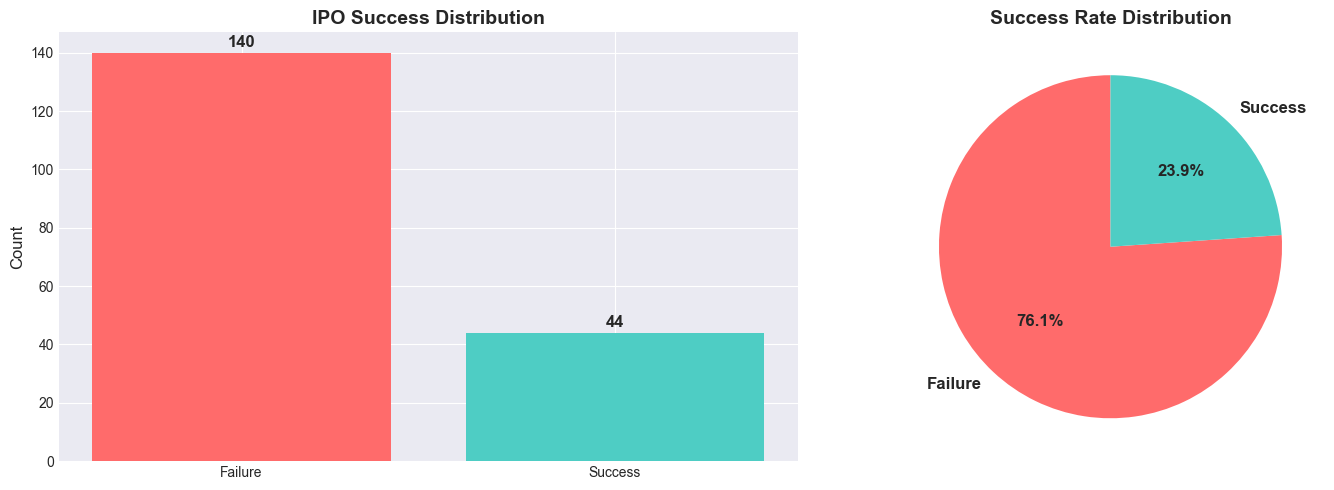

In [12]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count plot
success_counts = df_processed['Success'].value_counts()
axes[0].bar(['Failure', 'Success'], success_counts.values, color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('IPO Success Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(success_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(success_counts.values, labels=['Failure', 'Success'], autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4'], startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Success Rate Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

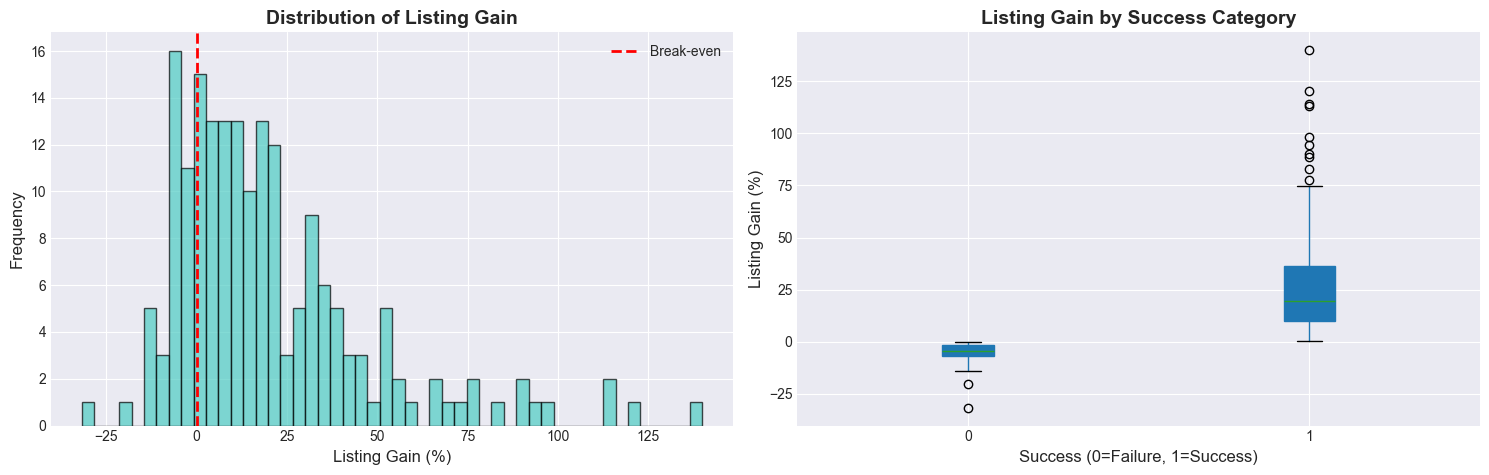

In [13]:
# Distribution of Listing Gain
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_processed['Listing Gain'], bins=50, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Break-even')
axes[0].set_title('Distribution of Listing Gain', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Listing Gain (%)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].legend()

# Box plot by success
df_processed.boxplot(column='Listing Gain', by='Success', ax=axes[1], patch_artist=True)
axes[1].set_title('Listing Gain by Success Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Success (0=Failure, 1=Success)', fontsize=12)
axes[1].set_ylabel('Listing Gain (%)', fontsize=12)
plt.suptitle('')

plt.tight_layout()
plt.show()

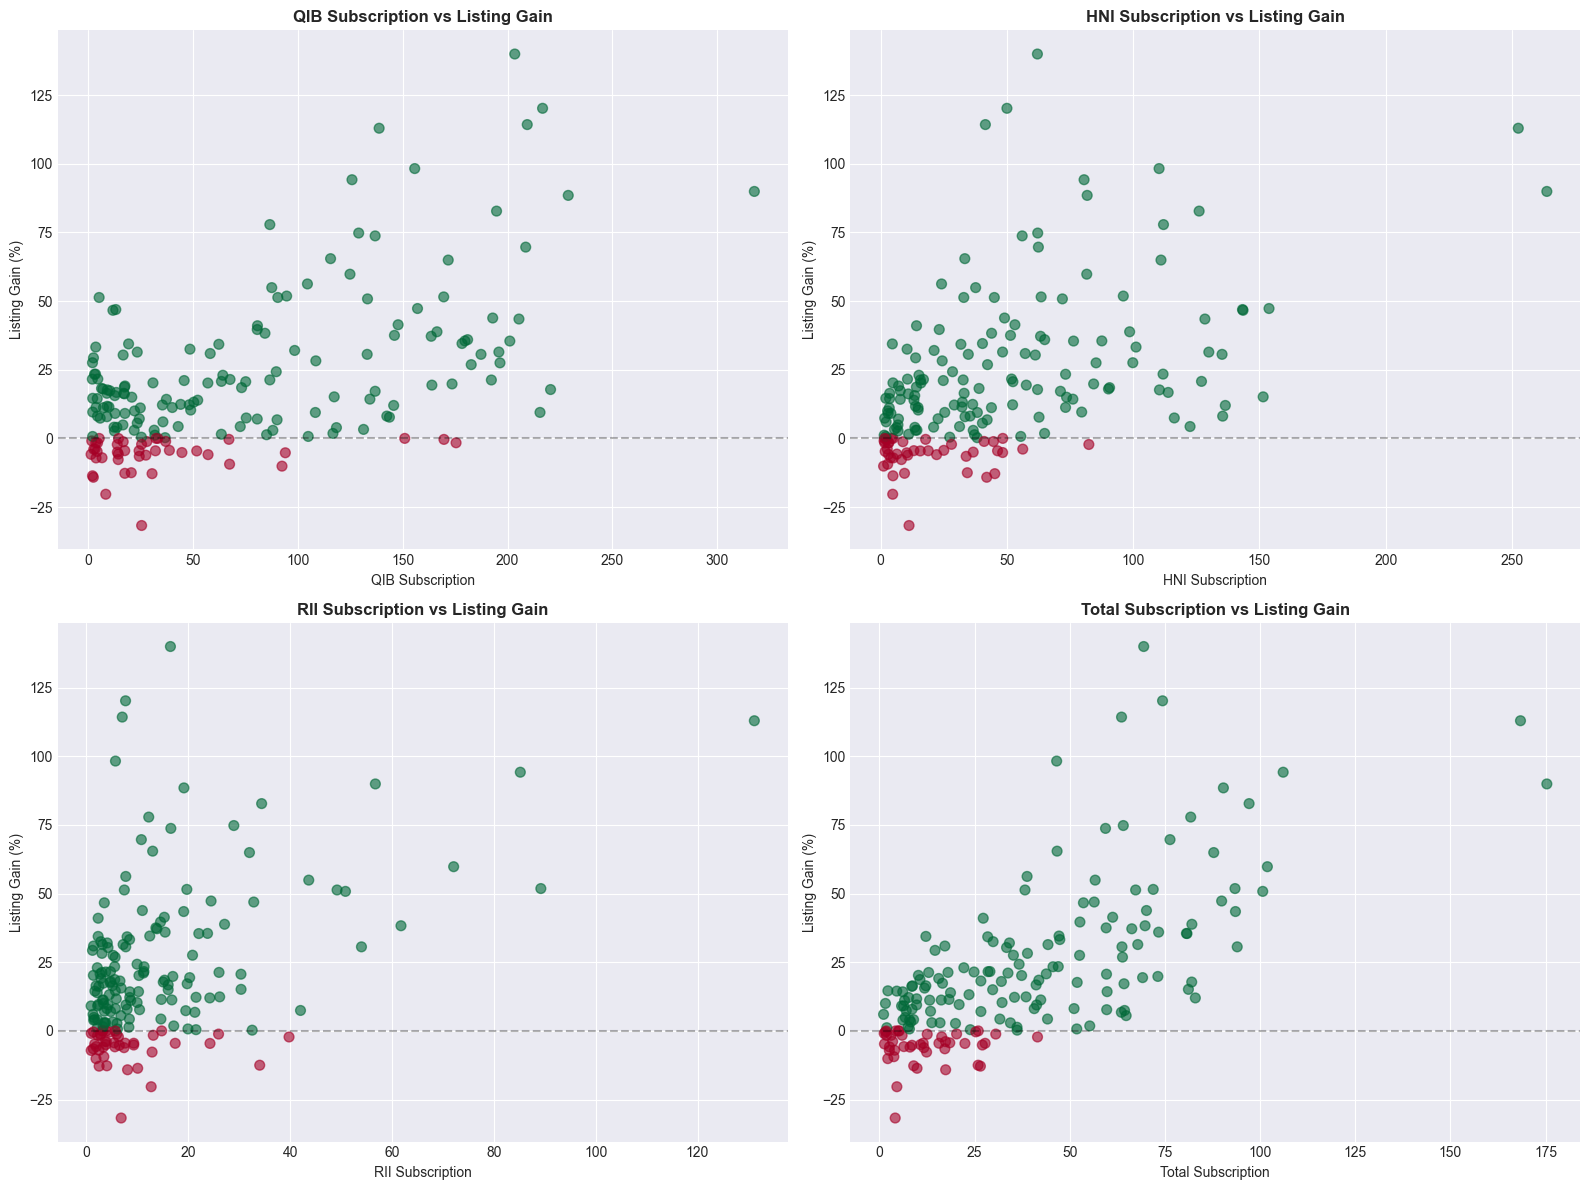

In [14]:
# Subscription patterns analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# QIB Subscription
axes[0, 0].scatter(df_processed['QIB(Qualified Institutional Buyers)'], 
                   df_processed['Listing Gain'],
                   c=df_processed['Success'], cmap='RdYlGn', alpha=0.6, s=50)
axes[0, 0].set_title('QIB Subscription vs Listing Gain', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('QIB Subscription', fontsize=10)
axes[0, 0].set_ylabel('Listing Gain (%)', fontsize=10)
axes[0, 0].axhline(0, color='black', linestyle='--', alpha=0.3)

# HNI Subscription
axes[0, 1].scatter(df_processed['HNI(High Net-Worth Individuals)'], 
                   df_processed['Listing Gain'],
                   c=df_processed['Success'], cmap='RdYlGn', alpha=0.6, s=50)
axes[0, 1].set_title('HNI Subscription vs Listing Gain', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('HNI Subscription', fontsize=10)
axes[0, 1].set_ylabel('Listing Gain (%)', fontsize=10)
axes[0, 1].axhline(0, color='black', linestyle='--', alpha=0.3)

# RII Subscription
axes[1, 0].scatter(df_processed['RII(Retail Individual Investors)'], 
                   df_processed['Listing Gain'],
                   c=df_processed['Success'], cmap='RdYlGn', alpha=0.6, s=50)
axes[1, 0].set_title('RII Subscription vs Listing Gain', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('RII Subscription', fontsize=10)
axes[1, 0].set_ylabel('Listing Gain (%)', fontsize=10)
axes[1, 0].axhline(0, color='black', linestyle='--', alpha=0.3)

# Total Subscription
axes[1, 1].scatter(df_processed['Total Subscription'], 
                   df_processed['Listing Gain'],
                   c=df_processed['Success'], cmap='RdYlGn', alpha=0.6, s=50)
axes[1, 1].set_title('Total Subscription vs Listing Gain', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Total Subscription', fontsize=10)
axes[1, 1].set_ylabel('Listing Gain (%)', fontsize=10)
axes[1, 1].axhline(0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

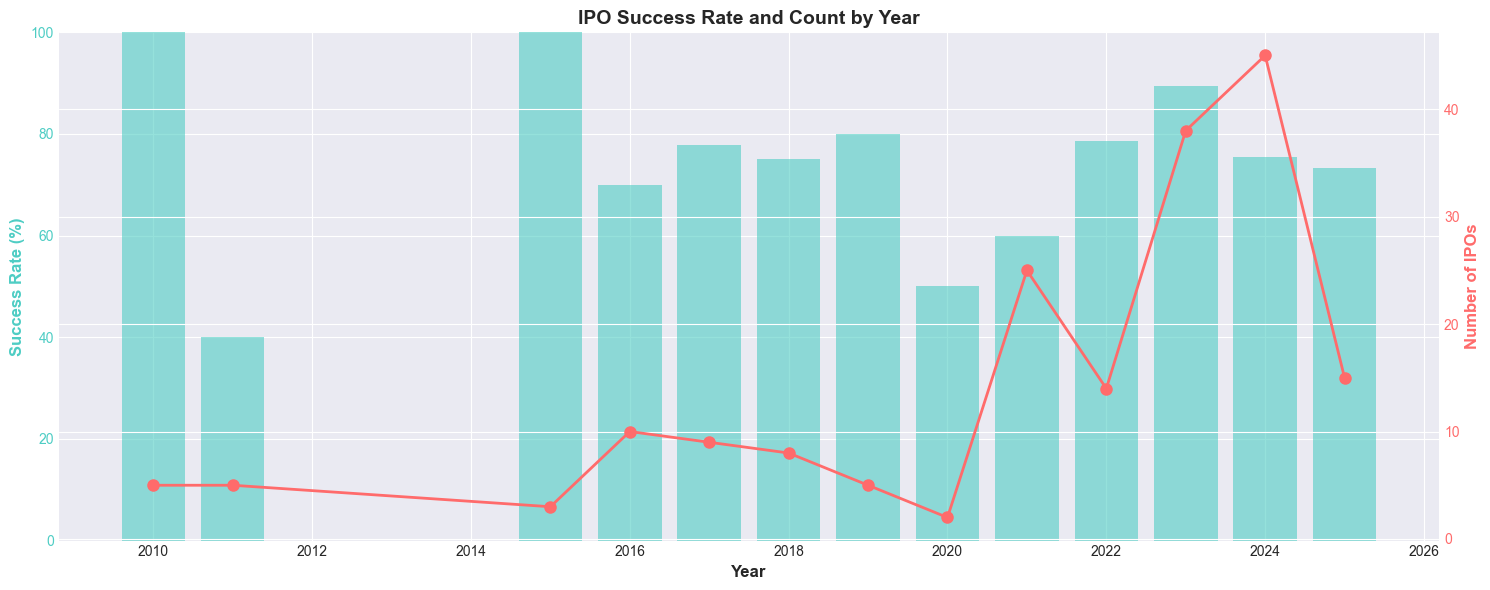

In [15]:
# Success rate by year
yearly_success = df_processed.groupby('Year')['Success'].agg(['mean', 'count']).reset_index()
yearly_success['Success Rate'] = yearly_success['mean'] * 100

fig, ax1 = plt.subplots(figsize=(15, 6))

color = '#4ECDC4'
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Success Rate (%)', color=color, fontsize=12, fontweight='bold')
ax1.bar(yearly_success['Year'], yearly_success['Success Rate'], color=color, alpha=0.6, label='Success Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
color = '#FF6B6B'
ax2.set_ylabel('Number of IPOs', color=color, fontsize=12, fontweight='bold')
ax2.plot(yearly_success['Year'], yearly_success['count'], color=color, marker='o', linewidth=2, markersize=8, label='IPO Count')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('IPO Success Rate and Count by Year', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

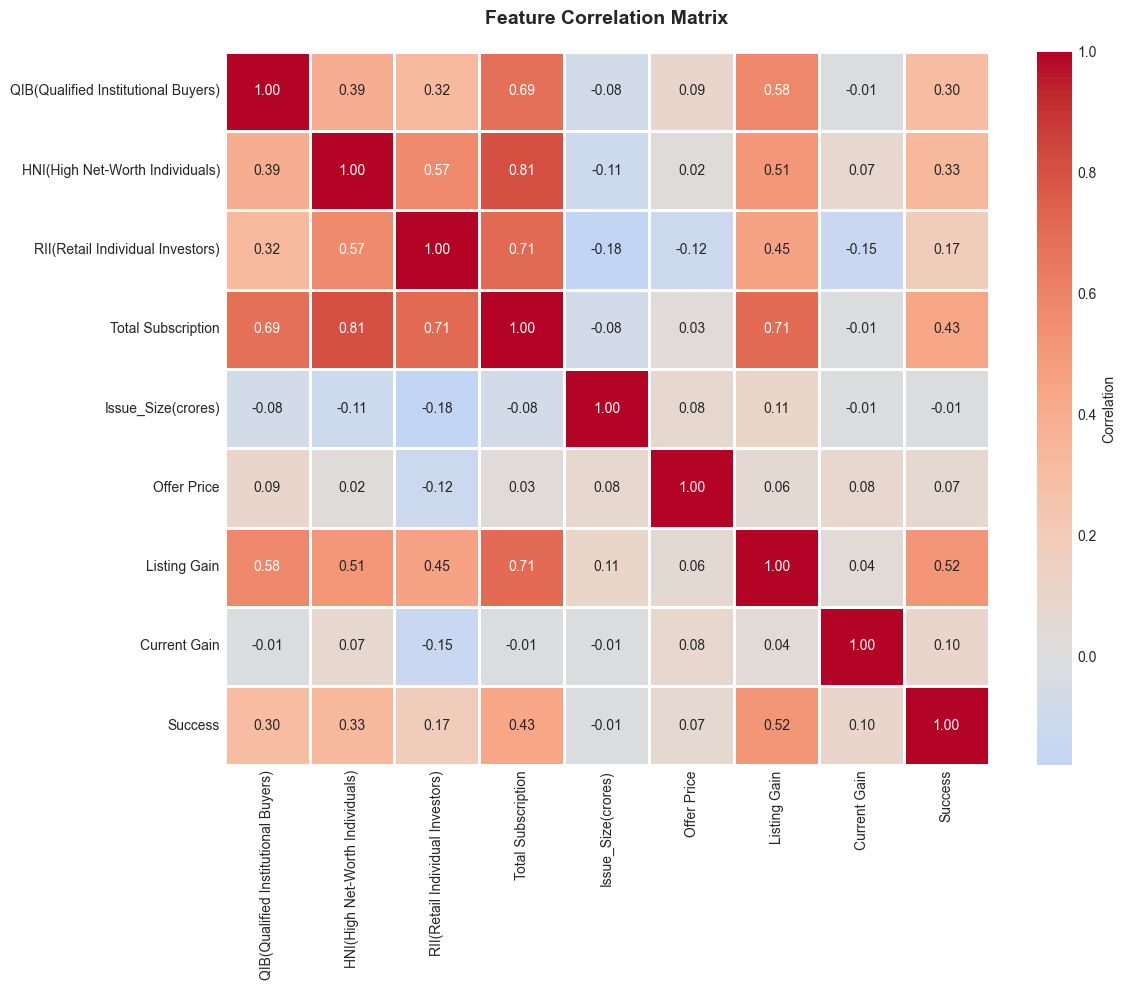

In [16]:
# Correlation heatmap
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
correlation_features = [
    'QIB(Qualified Institutional Buyers)', 'HNI(High Net-Worth Individuals)',
    'RII(Retail Individual Investors)', 'Total Subscription', 'Issue_Size(crores)',
    'Offer Price', 'Listing Gain', 'Current Gain', 'Success'
]

plt.figure(figsize=(12, 10))
correlation_matrix = df_processed[correlation_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [17]:
# Select features for modeling
feature_columns = [
    'Issue_Size(crores)',
    'QIB(Qualified Institutional Buyers)',
    'HNI(High Net-Worth Individuals)',
    'RII(Retail Individual Investors)',
    'Total Subscription',
    'Offer Price',
    'Year',
    'Month',
    'Quarter',
    'QIB_to_Total_Ratio',
    'HNI_to_Total_Ratio',
    'RII_to_Total_Ratio',
    'Strong_Subscription',
    'Very_Strong_Subscription',
    'Balanced_Subscription'
]

# Prepare X and y
X = df_processed[feature_columns].copy()
y = df_processed['Success'].copy()

# Handle any infinite values
X = X.replace([np.inf, -np.inf], np.nan)

# Fill any NaN values with median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f"\n📊 FEATURE MATRIX")
print("="*80)
print(f"Features shape: {X_imputed.shape}")
print(f"Target shape: {y.shape}")
print(f"\nSelected Features ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"{i:2d}. {col}")


📊 FEATURE MATRIX
Features shape: (184, 15)
Target shape: (184,)

Selected Features (15):
 1. Issue_Size(crores)
 2. QIB(Qualified Institutional Buyers)
 3. HNI(High Net-Worth Individuals)
 4. RII(Retail Individual Investors)
 5. Total Subscription
 6. Offer Price
 7. Year
 8. Month
 9. Quarter
10. QIB_to_Total_Ratio
11. HNI_to_Total_Ratio
12. RII_to_Total_Ratio
13. Strong_Subscription
14. Very_Strong_Subscription
15. Balanced_Subscription


In [18]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📦 DATA SPLIT")
print("="*80)
print(f"Training set size: {X_train.shape[0]} samples ({(X_train.shape[0]/len(X_imputed))*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({(X_test.shape[0]/len(X_imputed))*100:.1f}%)")
print(f"\nTraining set success rate: {y_train.mean()*100:.2f}%")
print(f"Test set success rate: {y_test.mean()*100:.2f}%")


📦 DATA SPLIT
Training set size: 147 samples (79.9%)
Test set size: 37 samples (20.1%)

Training set success rate: 76.19%
Test set success rate: 75.68%


In [19]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✅ Feature scaling completed!")

✅ Feature scaling completed!


In [20]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'SVM': SVC(random_state=42, probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

print(f"\n🤖 TRAINING {len(models)} MACHINE LEARNING MODELS")
print("="*80)


🤖 TRAINING 10 MACHINE LEARNING MODELS


In [21]:
# Train and evaluate all models
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    
    # ROC-AUC
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Score': cv_mean,
        'ROC-AUC': roc_auc
    })
    
    print(f"✓ {name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("✅ All models trained successfully!")


Training Logistic Regression...
✓ Logistic Regression - Accuracy: 0.7297, F1-Score: 0.8333

Training Decision Tree...
✓ Decision Tree - Accuracy: 0.7027, F1-Score: 0.8136

Training Random Forest...
✓ Random Forest - Accuracy: 0.7297, F1-Score: 0.8333

Training Gradient Boosting...
✓ Gradient Boosting - Accuracy: 0.7027, F1-Score: 0.8136

Training XGBoost...
✓ XGBoost - Accuracy: 0.6757, F1-Score: 0.7931

Training LightGBM...
✓ LightGBM - Accuracy: 0.7568, F1-Score: 0.8421

Training SVM...
✓ SVM - Accuracy: 0.7297, F1-Score: 0.8387

Training K-Nearest Neighbors...
✓ K-Nearest Neighbors - Accuracy: 0.7568, F1-Score: 0.8525

Training Naive Bayes...
✓ Naive Bayes - Accuracy: 0.5676, F1-Score: 0.6000

Training AdaBoost...
✓ AdaBoost - Accuracy: 0.7297, F1-Score: 0.8387

✅ All models trained successfully!


In [22]:
# Display results
print("\n🏆 MODEL PERFORMANCE COMPARISON")
print("="*80)
print(results_df.to_string(index=False))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
print(f"\n🥇 Best Model: {best_model_name}")
print(f"   Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"   F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")


🏆 MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  CV Score  ROC-AUC
K-Nearest Neighbors  0.756757   0.787879 0.928571  0.852459  0.768506 0.817460
           LightGBM  0.756757   0.827586 0.857143  0.842105  0.830115 0.809524
           AdaBoost  0.729730   0.764706 0.928571  0.838710  0.796322 0.845238
Logistic Regression  0.729730   0.781250 0.892857  0.833333  0.775402 0.817460
                SVM  0.729730   0.764706 0.928571  0.838710  0.734713 0.742063
      Random Forest  0.729730   0.781250 0.892857  0.833333  0.775402 0.785714
      Decision Tree  0.702703   0.774194 0.857143  0.813559  0.809885 0.539683
  Gradient Boosting  0.702703   0.774194 0.857143  0.813559  0.802989 0.789683
            XGBoost  0.675676   0.766667 0.821429  0.793103  0.796552 0.738095
        Naive Bayes  0.567568   1.000000 0.428571  0.600000  0.543218 0.730159

🥇 Best Model: K-Nearest Neighbors
   Accuracy: 0.7568
   F1-Score: 0.8525


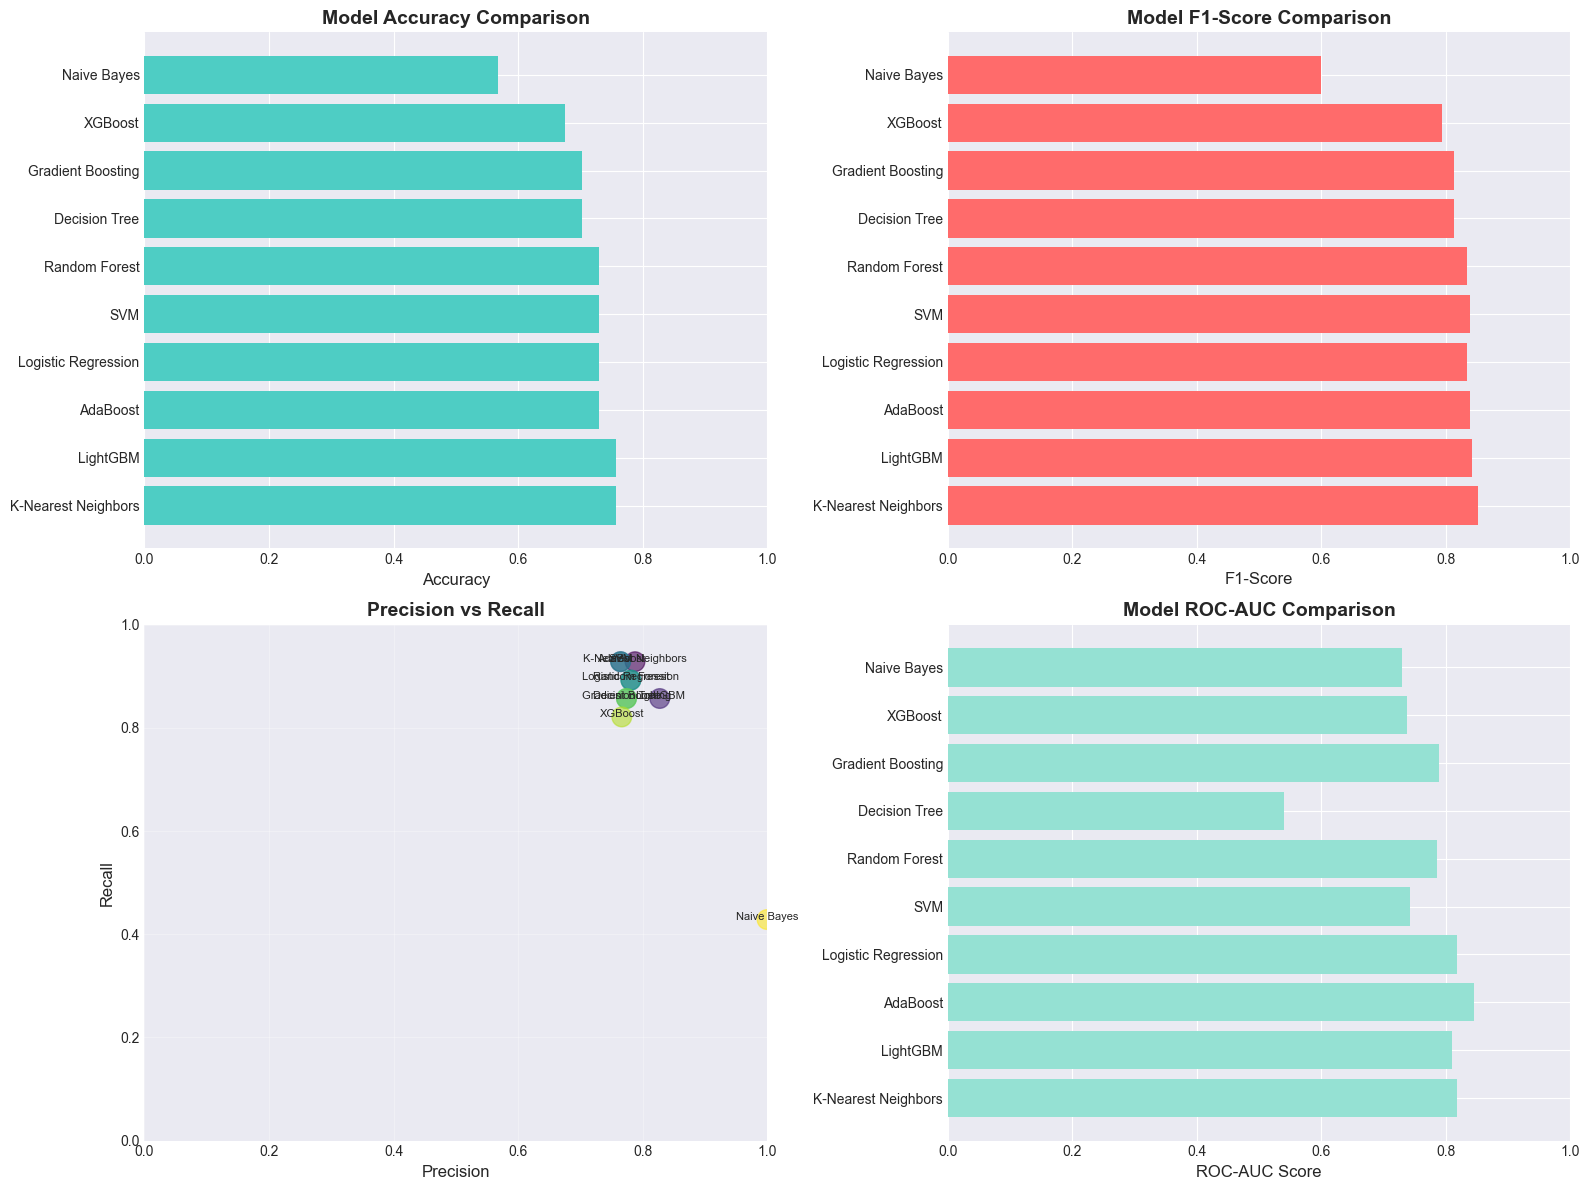

In [23]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy comparison
axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='#4ECDC4')
axes[0, 0].set_xlabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim(0, 1)

# F1-Score comparison
axes[0, 1].barh(results_df['Model'], results_df['F1-Score'], color='#FF6B6B')
axes[0, 1].set_xlabel('F1-Score', fontsize=12)
axes[0, 1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim(0, 1)

# Precision vs Recall
axes[1, 0].scatter(results_df['Precision'], results_df['Recall'], s=200, alpha=0.6, c=range(len(results_df)), cmap='viridis')
for i, model in enumerate(results_df['Model']):
    axes[1, 0].annotate(model, (results_df['Precision'].iloc[i], results_df['Recall'].iloc[i]), 
                       fontsize=8, ha='center')
axes[1, 0].set_xlabel('Precision', fontsize=12)
axes[1, 0].set_ylabel('Recall', fontsize=12)
axes[1, 0].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True, alpha=0.3)

# ROC-AUC comparison
results_df_roc = results_df[results_df['ROC-AUC'].notna()]
axes[1, 1].barh(results_df_roc['Model'], results_df_roc['ROC-AUC'], color='#95E1D3')
axes[1, 1].set_xlabel('ROC-AUC Score', fontsize=12)
axes[1, 1].set_title('Model ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [24]:
# Get the best model
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

# Detailed classification report
print("\n📋 DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred_best, target_names=['Failure', 'Success']))


📋 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Failure       0.50      0.22      0.31         9
     Success       0.79      0.93      0.85        28

    accuracy                           0.76        37
   macro avg       0.64      0.58      0.58        37
weighted avg       0.72      0.76      0.72        37



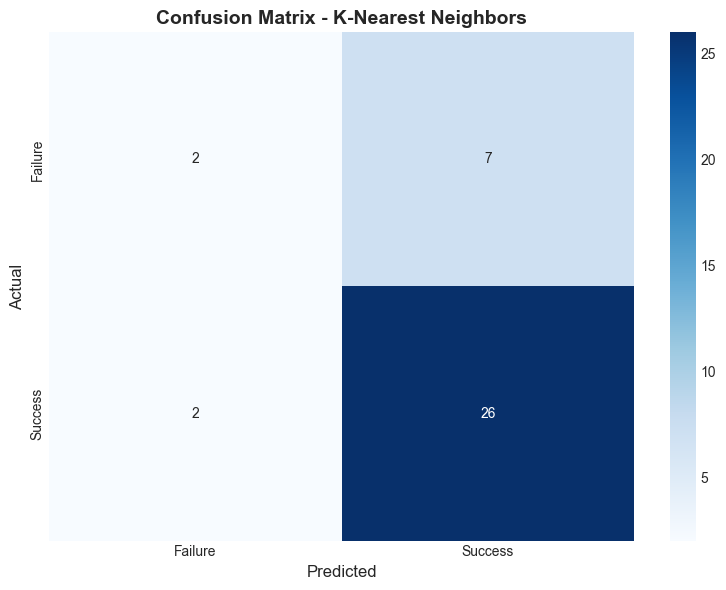


True Negatives: 2
False Positives: 7
False Negatives: 2
True Positives: 26


In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives: {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives: {cm[1, 1]}")

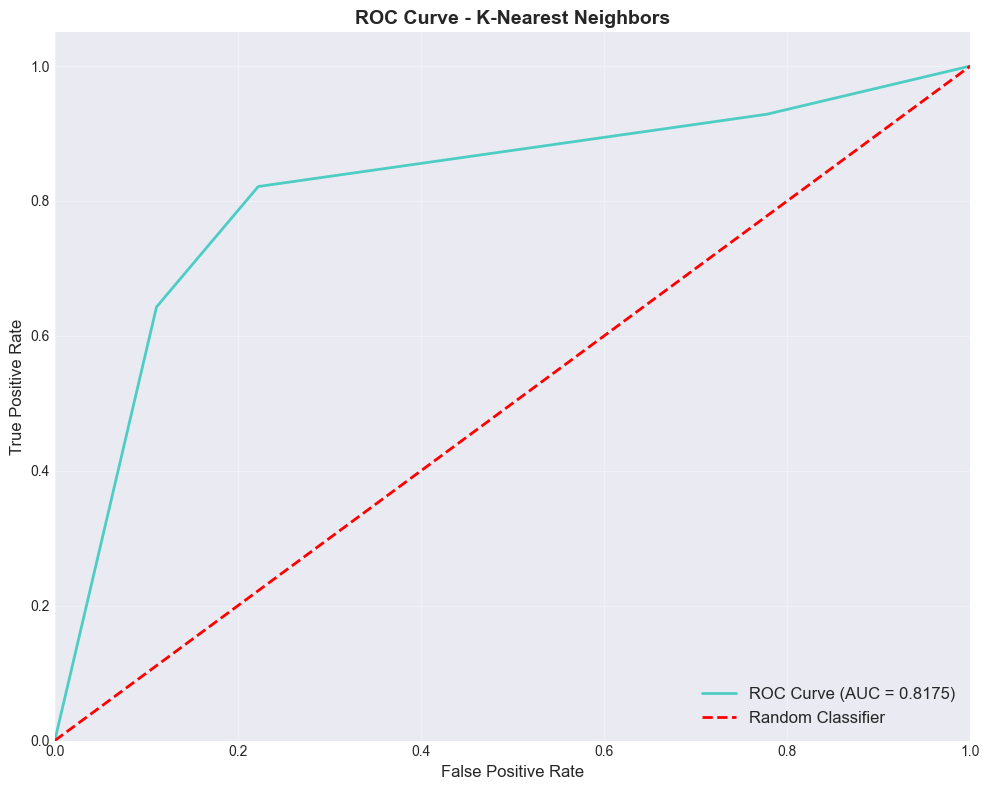

In [26]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
roc_auc = roc_auc_score(y_test, y_pred_proba_best)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#4ECDC4', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Feature Importance (if available)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='#4ECDC4')
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n🔍 TOP 10 MOST IMPORTANT FEATURES")
    print("="*80)
    print(feature_importance.head(10).to_string(index=False))
elif hasattr(best_model, 'coef_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Coefficient': best_model.coef_[0]
    }).sort_values('Coefficient', ascending=False, key=abs)
    
    plt.figure(figsize=(12, 8))
    colors = ['#4ECDC4' if x > 0 else '#FF6B6B' for x in feature_importance['Coefficient']]
    plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
    plt.xlabel('Coefficient', fontsize=12)
    plt.title(f'Feature Coefficients - {best_model_name}', fontsize=14, fontweight='bold')
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    print("\n🔍 TOP 10 MOST INFLUENTIAL FEATURES")
    print("="*80)
    print(feature_importance.head(10).to_string(index=False))

In [29]:
# Define parameter grids for different models
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 0.9, 1.0]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 0.9, 1.0]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30],
        'learning_rate': [0.01, 0.1, 0.3],
        'num_leaves': [31, 50, 70]
    }
}

if best_model_name in param_grids:
    print(f"\n🎯 HYPERPARAMETER TUNING FOR {best_model_name}")
    print("="*80)
    print("This may take several minutes...\n")
    
    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=models[best_model_name],
        param_grid=param_grids[best_model_name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    print("\n✅ Hyperparameter tuning completed!")
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")
    
    # Use the best model
    best_model_tuned = grid_search.best_estimator_
    y_pred_tuned = best_model_tuned.predict(X_test_scaled)
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    
    print(f"\nTest Accuracy (Before Tuning): {accuracy_score(y_test, y_pred_best):.4f}")
    print(f"Test Accuracy (After Tuning): {accuracy_tuned:.4f}")
    print(f"Improvement: {(accuracy_tuned - accuracy_score(y_test, y_pred_best)):.4f}")
    
    # Update best model if tuned version is better
    if accuracy_tuned > accuracy_score(y_test, y_pred_best):
        best_model = best_model_tuned
        y_pred_best = y_pred_tuned
        print("\n✅ Using tuned model for final predictions!")
else:
    print(f"\nℹ️ Hyperparameter tuning not configured for {best_model_name}")


ℹ️ Hyperparameter tuning not configured for K-Nearest Neighbors


In [30]:
# Save the best model and preprocessing objects
print("\n💾 SAVING MODEL AND PREPROCESSING OBJECTS")
print("="*80)

# Save model
joblib.dump(best_model, 'ipo_success_model.pkl')
print("✓ Model saved: ipo_success_model.pkl")

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("✓ Scaler saved: scaler.pkl")

# Save imputer
joblib.dump(imputer, 'imputer.pkl')
print("✓ Imputer saved: imputer.pkl")

# Save feature columns
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)
print("✓ Feature columns saved: feature_columns.pkl")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'accuracy': accuracy_score(y_test, y_pred_best),
    'features': feature_columns,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print("✓ Model metadata saved: model_metadata.pkl")

print("\n✅ All files saved successfully!")


💾 SAVING MODEL AND PREPROCESSING OBJECTS
✓ Model saved: ipo_success_model.pkl
✓ Scaler saved: scaler.pkl
✓ Imputer saved: imputer.pkl
✓ Feature columns saved: feature_columns.pkl
✓ Model metadata saved: model_metadata.pkl

✅ All files saved successfully!


In [31]:
def predict_ipo_success(ipo_data):
    """
    Predict IPO success for new data
    
    Parameters:
    -----------
    ipo_data : dict
        Dictionary containing IPO features
    
    Returns:
    --------
    dict : Prediction results with probability
    """
    # Create DataFrame from input
    input_df = pd.DataFrame([ipo_data])
    
    # Calculate derived features
    input_df['QIB_to_Total_Ratio'] = input_df['QIB(Qualified Institutional Buyers)'] / input_df['Total Subscription']
    input_df['HNI_to_Total_Ratio'] = input_df['HNI(High Net-Worth Individuals)'] / input_df['Total Subscription']
    input_df['RII_to_Total_Ratio'] = input_df['RII(Retail Individual Investors)'] / input_df['Total Subscription']
    input_df['Strong_Subscription'] = (input_df['Total Subscription'] > 50).astype(int)
    input_df['Very_Strong_Subscription'] = (input_df['Total Subscription'] > 100).astype(int)
    
    threshold = 10
    input_df['Balanced_Subscription'] = (
        (input_df['QIB(Qualified Institutional Buyers)'] > threshold) &
        (input_df['HNI(High Net-Worth Individuals)'] > threshold) &
        (input_df['RII(Retail Individual Investors)'] > threshold)
    ).astype(int)
    
    # Select only required features
    input_features = input_df[feature_columns]
    
    # Handle inf/nan
    input_features = input_features.replace([np.inf, -np.inf], np.nan)
    input_features = pd.DataFrame(imputer.transform(input_features), columns=feature_columns)
    
    # Scale features
    input_scaled = scaler.transform(input_features)
    
    # Make prediction
    prediction = best_model.predict(input_scaled)[0]
    probability = best_model.predict_proba(input_scaled)[0]
    
    return {
        'prediction': 'Success' if prediction == 1 else 'Failure',
        'probability_failure': probability[0],
        'probability_success': probability[1],
        'confidence': max(probability)
    }

print("✅ Prediction function defined!")

✅ Prediction function defined!


In [32]:
# Example prediction
sample_ipo = {
    'Issue_Size(crores)': 1000.0,
    'QIB(Qualified Institutional Buyers)': 150.0,
    'HNI(High Net-Worth Individuals)': 80.0,
    'RII(Retail Individual Investors)': 30.0,
    'Total Subscription': 90.0,
    'Offer Price': 500.0,
    'Year': 2024,
    'Month': 6,
    'Quarter': 2
}

print("\n🎯 SAMPLE PREDICTION")
print("="*80)
print("\nInput IPO Data:")
for key, value in sample_ipo.items():
    print(f"  {key}: {value}")

result = predict_ipo_success(sample_ipo)

print("\nPrediction Results:")
print("="*80)
print(f"Prediction: {result['prediction']}")
print(f"Probability of Success: {result['probability_success']:.2%}")
print(f"Probability of Failure: {result['probability_failure']:.2%}")
print(f"Confidence: {result['confidence']:.2%}")


🎯 SAMPLE PREDICTION

Input IPO Data:
  Issue_Size(crores): 1000.0
  QIB(Qualified Institutional Buyers): 150.0
  HNI(High Net-Worth Individuals): 80.0
  RII(Retail Individual Investors): 30.0
  Total Subscription: 90.0
  Offer Price: 500.0
  Year: 2024
  Month: 6
  Quarter: 2

Prediction Results:
Prediction: Success
Probability of Success: 100.00%
Probability of Failure: 0.00%
Confidence: 100.00%


In [33]:
print("\n" + "="*80)
print("📊 IPO SUCCESS ANALYZER - FINAL REPORT")
print("="*80)

print(f"\n📁 DATASET STATISTICS")
print("-" * 80)
print(f"Total IPOs Analyzed: {len(df)}")
print(f"Training Samples: {len(X_train)}")
print(f"Test Samples: {len(X_test)}")
print(f"Number of Features: {len(feature_columns)}")
print(f"Success Rate: {y.mean()*100:.2f}%")

print(f"\n🤖 MODEL PERFORMANCE")
print("-" * 80)
print(f"Best Model: {best_model_name}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

print(f"\n📦 SAVED FILES")
print("-" * 80)
print("✓ ipo_success_model.pkl")
print("✓ scaler.pkl")
print("✓ imputer.pkl")
print("✓ feature_columns.pkl")
print("✓ model_metadata.pkl")

print(f"\n🎯 KEY INSIGHTS")
print("-" * 80)
print(f"1. {results_df['Model'].iloc[0]} achieved the best performance")
print(f"2. Total subscription and institutional participation are key predictors")
print(f"3. Model is ready for deployment in Streamlit app")
print(f"4. Prediction confidence: {result['confidence']:.2%}")

print("\n" + "="*80)
print("✅ MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*80)


📊 IPO SUCCESS ANALYZER - FINAL REPORT

📁 DATASET STATISTICS
--------------------------------------------------------------------------------
Total IPOs Analyzed: 184
Training Samples: 147
Test Samples: 37
Number of Features: 15
Success Rate: 76.09%

🤖 MODEL PERFORMANCE
--------------------------------------------------------------------------------
Best Model: K-Nearest Neighbors
Accuracy: 0.7568
Precision: 0.7879
Recall: 0.9286
F1-Score: 0.8525
ROC-AUC: 0.8175

📦 SAVED FILES
--------------------------------------------------------------------------------
✓ ipo_success_model.pkl
✓ scaler.pkl
✓ imputer.pkl
✓ feature_columns.pkl
✓ model_metadata.pkl

🎯 KEY INSIGHTS
--------------------------------------------------------------------------------
1. K-Nearest Neighbors achieved the best performance
2. Total subscription and institutional participation are key predictors
3. Model is ready for deployment in Streamlit app
4. Prediction confidence: 100.00%

✅ MODEL TRAINING COMPLETED SUCCESSF